# Age-group reliability check — KT LivePOP & Movement (Sudogwon, 2023-01)

**목적**: KT 생활인구 / Movement 데이터를 어린이(0–9세)와 청소년(10–19세) 분석에 쓰기 전에, KT 데이터 자체로 "잡힘 정도"를 체크.

**가설**

- 0–9세는 휴대폰 미보유율이 높음 → KT 시그널링이 못 잡거나, 보호자 단말로 잡혀 실제 위치가 왜곡될 가능성.
- 10–19세는 휴대폰은 있으나 학교에 묶여 있음 → 이동량 자체가 적게 잡힐 가능성.
- 비교군: 20–29, 30–39세 (성인, KT가 가장 잘 잡는 구간으로 가정).

**데이터 한계 (1월)**

- **2023-01은 대학·초중고 모두 방학 기간** → 학교 효과를 직접 볼 수 없음.
- 학원·공휴일·설 연휴(1/21–24) 효과만 관측 가능.
- 결론은 학기 중 데이터(예: 2023-05 또는 2023-10)와 함께 봐야 최종 판단 가능. 본 노트북은 "방학 모드 baseline + 의심 신호 탐지".

**비교 범위**

- 본 노트북은 **KT 데이터 내부 비교만** 수행 (주민등록 외부 비교 제외).
- 평일/주말/공휴일 분리: 1/1, 1/21–24를 공휴일로 처리.

In [ ]:
import os
import sys
import polars as pl
import polars.selectors as cs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import datetime
from pathlib import Path

# Resolve project root so relative data paths work regardless of where the kernel starts.
_HERE = Path.cwd()
PROJECT_ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Data layout (post rsync cleanup):
#   data/raw/_OLD_age10/  ← 10-age LivePOP parquets (this notebook reads from here via DATA_DIR)
#   data/raw/movement/    ← Movement OD (cell 10 reads from here)
#   data/raw/livepop_age5/  ← 5-age LivePOP (not used in this notebook)
# DATA_DIR points to _OLD_age10 because cells reference `DATA_DIR / 'livepop_sudogwon_*.parquet'`;
# the movement cell is patched separately below to read from MOVEMENT_DIR.
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "_OLD_age10"
MOVEMENT_DIR = PROJECT_ROOT / "data" / "raw" / "movement"
MAPPING_DIR = PROJECT_ROOT / "data" / "mapping"
OUT_DIR = PROJECT_ROOT / "outputs" / "age_validation_2023_01"
OUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_AGES = [0, 10]            # 0-9, 10-19  (검증 대상)
REF_AGES = [20, 30]              # 20-29, 30-39 (성인 비교군)
ALL_AGES = TARGET_AGES + REF_AGES
AGE_LABELS = {0: '0-9', 10: '10-19', 20: '20-29', 30: '30-39'}
AGE_COLORS = {0: 'C0', 10: 'C1', 20: 'C2', 30: 'C3'}

HOLIDAYS_202301 = {20230101, 20230121, 20230122, 20230123, 20230124}

def classify_day(yyyymmdd: int) -> str:
    d = datetime.date(yyyymmdd // 10000,
                      (yyyymmdd // 100) % 100,
                      yyyymmdd % 100)
    if yyyymmdd in HOLIDAYS_202301 or d.weekday() >= 5:
        return 'weekend'
    return 'weekday'

plt.rcParams['figure.dpi'] = 120

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:    ", DATA_DIR, "→ livepop_sudogwon_*.parquet")
print("MOVEMENT_DIR:", MOVEMENT_DIR, "→ movement_sudogwon_*.parquet")
print("MAPPING_DIR: ", MAPPING_DIR)
print("OUT_DIR:     ", OUT_DIR)

## 1. LivePOP 연령별 총량 점검

> 단순한 sanity check. 1월 24×31시간 평균 인구를 연령별로 집계.
> 정상이면 인구 비율이 주민등록과 비슷해야 하지만 — 이 노트북에서는 외부 비교는 하지 않고 KT 내부 절대값/비율만 본다.
> 0–9세 인구가 20–29세 대비 너무 작으면 "KT가 어린이를 못 잡고 있다"는 1차 신호.

In [2]:
livepop = pl.read_parquet(DATA_DIR / 'livepop_sudogwon_202301.parquet')
livepop = livepop.filter(pl.col('age_10').is_in(ALL_AGES))
print(f'LivePOP rows (filtered): {len(livepop):,}')

# 24h x 31day 평균 인구
age_avg_pop = (
    livepop.group_by('age_10')
           .agg((pl.col('pop').sum() / (24 * 31)).alias('avg_pop_total'))
           .sort('age_10')
)
print(age_avg_pop)

fig, ax = plt.subplots(figsize=(8, 5))
ages = age_avg_pop['age_10'].to_list()
vals = age_avg_pop['avg_pop_total'].to_list()
ax.bar([AGE_LABELS[a] for a in ages], vals,
       color=[AGE_COLORS[a] for a in ages])
ax.set_ylabel('Average population (count)')
ax.set_title('Average LivePOP by age group (Sudogwon, Jan 2023)')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / '01_livepop_total_by_age.png', dpi=120)
plt.show()

FileNotFoundError: No such file or directory (os error 2): ../data/raw/livepop_sudogwon_202301.parquet

## 2. LivePOP 시간대별 변동 (학교/직장 시그널)

> 연령대별로 시간대에 따라 인구가 얼마나 변하는가? (24시간 평균=1로 정규화하여 모양만 비교)
> 
> 가설:
> - 20–30대: 출퇴근으로 거주동 인구가 낮에 빠지고 저녁에 돌아옴 → 변동 큼.
> - 0–9세: 1월(방학)이라 변동 작을 것. 변동이 너무 작으면 "KT가 어린이의 낮 이동을 못 잡는다"는 신호.
> - 10–19세: 학원 시간대(저녁)에 약한 변동? 저녁 피크가 보이면 학원 신호.

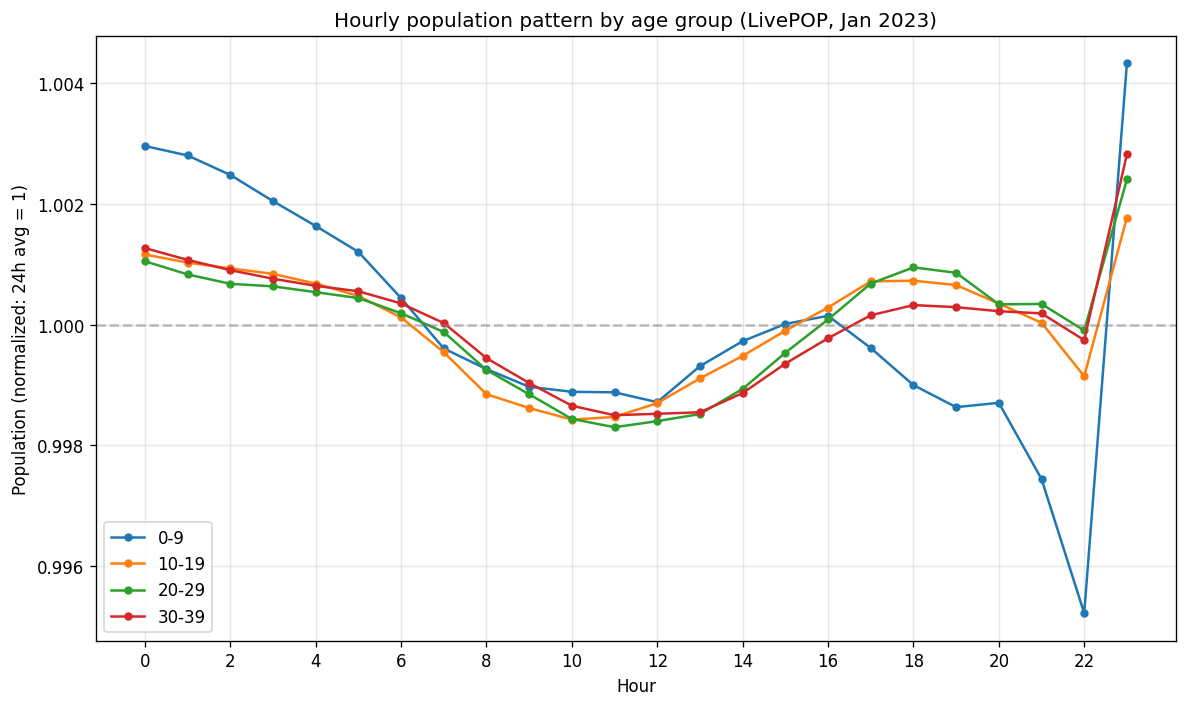

In [3]:
hourly_by_age = (
    livepop.group_by(['hour', 'age_10'])
           .agg(pl.col('pop').sum().alias('pop_sum'))
           .sort(['age_10', 'hour'])
)

hourly_norm = hourly_by_age.with_columns(
    (pl.col('pop_sum') / pl.col('pop_sum').mean().over('age_10'))
    .alias('pop_normalized')
)

fig, ax = plt.subplots(figsize=(10, 6))
for age in ALL_AGES:
    sub = hourly_norm.filter(pl.col('age_10') == age).sort('hour')
    ax.plot(sub['hour'].to_numpy(), sub['pop_normalized'].to_numpy(),
            label=AGE_LABELS[age], color=AGE_COLORS[age],
            marker='o', markersize=4)
ax.set_xlabel('Hour')
ax.set_ylabel('Population (normalized: 24h avg = 1)')
ax.set_title('Hourly population pattern by age group (LivePOP, Jan 2023)')
ax.set_xticks(range(0, 24, 2))
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / '02_livepop_hourly_pattern.png', dpi=120)
plt.show()

### 해석 힌트

- 정규화된 곡선의 진폭(peak-to-trough)이 클수록 "낮 시간에 다른 곳으로 이동하는" 인구.
- 0–9세 변동이 0에 가까우면 두 가지 해석이 동시에 가능:
  1. 어린이의 낮 활동지가 거주지와 같은 동에 있다 (어린이집/초등학교가 동 안).
  2. KT가 어린이의 동간 이동을 시그널로 잡지 못한다.
- → 확인하려면 Section 7(평일 9시 vs 주말 9시 행정동 분포 비교)을 같이 봐야 함.
- 20–30대 곡선의 골(주간 감소)과 봉(저녁 회복)이 명확하다면 이 데이터가 출퇴근 신호를 잘 잡는다는 뜻 → 비교 baseline으로 사용 가능.

## 3. Day-Night Ratio (행정동 × 연령)

> 시간대 변동을 한 숫자로 압축: **Day(13시) / Night(04시)** 인구 비율.
> 
> - ratio < 1: "낮에 빠져나가는" 거주지
> - ratio > 1: "낮에 모이는" 활동지/업무지구
> - ratio ≈ 1: 24시간 정적 (어린이/노인/거주만 가능한 외곽 등)
> 
> 연령별 분포(boxplot)로 비교. 0–9세 분포가 ratio≈1 부근에 좁게 몰려 있으면 "KT가 어린이의 동간 이동을 안 잡는다"는 강한 신호.

/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_2453/3092883157.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[AGE_LABELS[a] for a in ALL_AGES], showfliers=False)


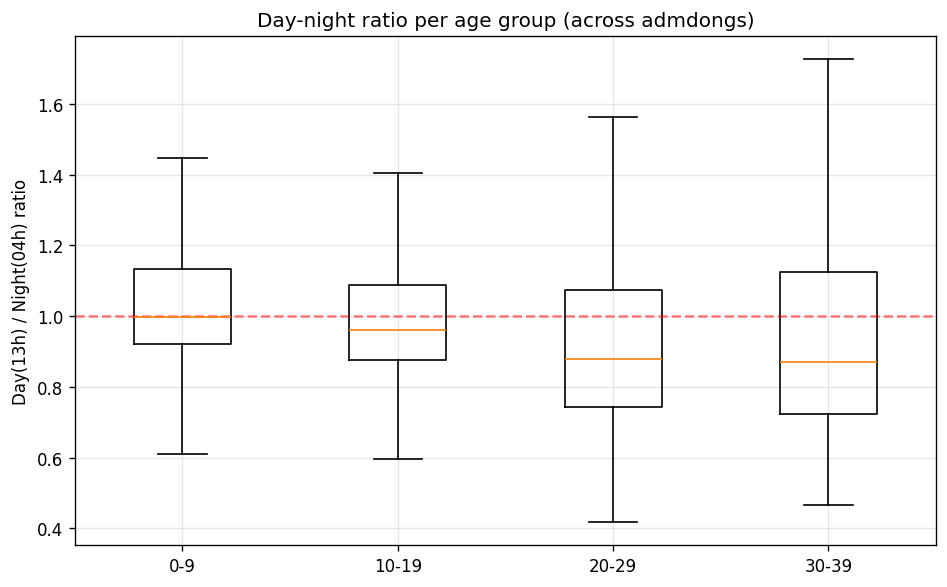

shape: (4, 5)
┌────────┬──────────┬──────────┬──────────┬──────────┐
│ age_10 ┆ median   ┆ q25      ┆ q75      ┆ std      │
│ ---    ┆ ---      ┆ ---      ┆ ---      ┆ ---      │
│ i8     ┆ f64      ┆ f64      ┆ f64      ┆ f64      │
╞════════╪══════════╪══════════╪══════════╪══════════╡
│ 0      ┆ 0.997947 ┆ 0.922328 ┆ 1.1321   ┆ 0.347996 │
│ 10     ┆ 0.960462 ┆ 0.877122 ┆ 1.088501 ┆ 0.322996 │
│ 20     ┆ 0.87733  ┆ 0.743206 ┆ 1.072753 ┆ 0.693447 │
│ 30     ┆ 0.869628 ┆ 0.721793 ┆ 1.125002 ┆ 0.857062 │
└────────┴──────────┴──────────┴──────────┴──────────┘


In [4]:
day_night = (
    livepop.filter(pl.col('hour').is_in([4, 13]))
           .group_by(['admdong_cd', 'admdong_nm', 'age_10', 'hour'])
           .agg(pl.col('pop').mean().alias('pop_avg'))
           .pivot(on='hour',
                  index=['admdong_cd', 'admdong_nm', 'age_10'],
                  values='pop_avg')
           .rename({'4': 'night_04', '13': 'day_13'})
           .with_columns(
               (pl.col('day_13') / pl.col('night_04')).alias('day_night_ratio'),
           )
           .filter(pl.col('night_04') > 10)   # 노이즈 동 제외
)

fig, ax = plt.subplots(figsize=(8, 5))
data = [day_night.filter(pl.col('age_10') == age)['day_night_ratio'].to_numpy()
        for age in ALL_AGES]
ax.boxplot(data, labels=[AGE_LABELS[a] for a in ALL_AGES], showfliers=False)
ax.set_ylabel('Day(13h) / Night(04h) ratio')
ax.set_title('Day-night ratio per age group (across admdongs)')
ax.axhline(1.0, color='r', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / '03_day_night_ratio.png', dpi=120)
plt.show()

summary = (
    day_night.group_by('age_10')
             .agg([
                 pl.col('day_night_ratio').median().alias('median'),
                 pl.col('day_night_ratio').quantile(0.25).alias('q25'),
                 pl.col('day_night_ratio').quantile(0.75).alias('q75'),
                 pl.col('day_night_ratio').std().alias('std'),
             ])
             .sort('age_10')
)
print(summary)

## 4. Movement 연령별 총 이동량

> KT Movement에서 연령대별 1월 전체 이동량(sum of `total`).
> 인구 보정을 위해 "인구 1인당 월 이동 횟수" = total / avg_pop 도 함께.
> 
> 0–9세의 인당 이동 횟수가 20–29세 대비 매우 작다면 → "KT가 어린이 이동을 거의 못 잡는다"는 강한 신호.

In [ ]:
movement = pl.read_parquet(MOVEMENT_DIR / 'movement_sudogwon_202301.parquet')
movement = movement.filter(pl.col('age_10').is_in(ALL_AGES))
print(f'Movement rows (filtered): {len(movement):,}')

move_by_age = (
    movement.group_by('age_10')
            .agg(pl.col('total').sum().alias('total_moves'))
            .sort('age_10')
)

merged = move_by_age.join(age_avg_pop, on='age_10').with_columns(
    (pl.col('total_moves') / pl.col('avg_pop_total'))
    .alias('moves_per_person_month')
)
print(merged)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ages = merged['age_10'].to_list()
axes[0].bar([AGE_LABELS[a] for a in ages], merged['total_moves'].to_list(),
            color=[AGE_COLORS[a] for a in ages])
axes[0].set_title('Total movements by age group (Jan 2023)')
axes[0].set_ylabel('Movement count (sum of total)')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar([AGE_LABELS[a] for a in ages],
            merged['moves_per_person_month'].to_list(),
            color=[AGE_COLORS[a] for a in ages])
axes[1].set_title('Moves per capita per month (KT-detected)')
axes[1].set_ylabel('Moves / person / month')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / '04_movement_total_by_age.png', dpi=120)
plt.show()

## 5. Movement 시간대별 패턴

> 연령대별 시간대별 이동량 (24h 평균=1로 정규화).
> 
> - 20–30대: 8시·18시 출퇴근 피크 명확해야 정상.
> - 10–19세: 1월(방학)이라 등하교 피크 약할 것. 17–22시 학원 시간대 봉오리가 보이는지 체크.
> - 0–9세: 거의 평탄? 평탄하면 어린이가 "KT 시그널을 거의 안 만든다"는 신호.

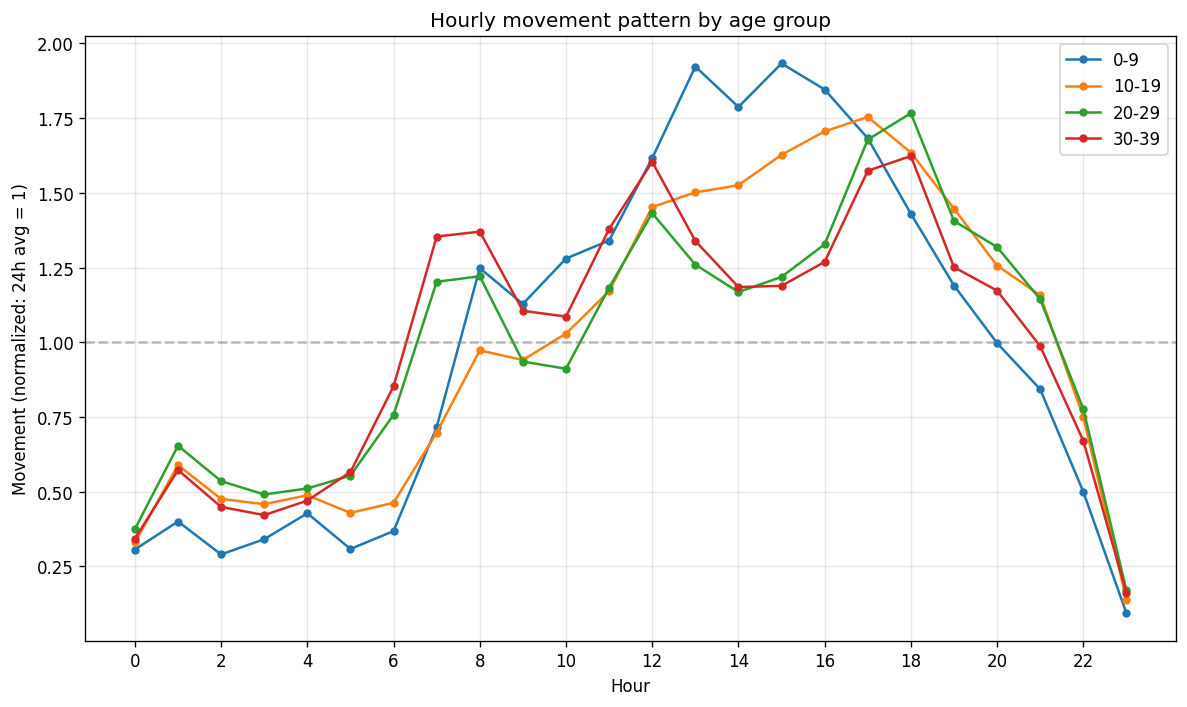

In [6]:
hourly_move = (
    movement.group_by(['hour', 'age_10'])
            .agg(pl.col('total').sum().alias('moves'))
            .sort(['age_10', 'hour'])
)
hourly_move_norm = hourly_move.with_columns(
    (pl.col('moves') / pl.col('moves').mean().over('age_10'))
    .alias('moves_normalized')
)

fig, ax = plt.subplots(figsize=(10, 6))
for age in ALL_AGES:
    sub = hourly_move_norm.filter(pl.col('age_10') == age).sort('hour')
    ax.plot(sub['hour'].to_numpy(), sub['moves_normalized'].to_numpy(),
            label=AGE_LABELS[age], color=AGE_COLORS[age],
            marker='o', markersize=4)
ax.set_xlabel('Hour')
ax.set_ylabel('Movement (normalized: 24h avg = 1)')
ax.set_title('Hourly movement pattern by age group')
ax.set_xticks(range(0, 24, 2))
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / '05_movement_hourly_pattern.png', dpi=120)
plt.show()

## 6. 평일 vs 주말/공휴일

> `classify_day`로 평일/주말+공휴일 분리 후 시간대 패턴 비교.
> 
> - 학원 효과: 평일 17–22시 10–19세 봉오리 → 평일에만 두드러질 것.
> - 출퇴근 효과: 평일 20–30대 8시·18시 피크.
> - 0–9세 평일/주말 차이가 거의 없다면: 1월에 어린이 활동이 KT에 "평일" 시그널을 거의 안 만든다는 뜻.

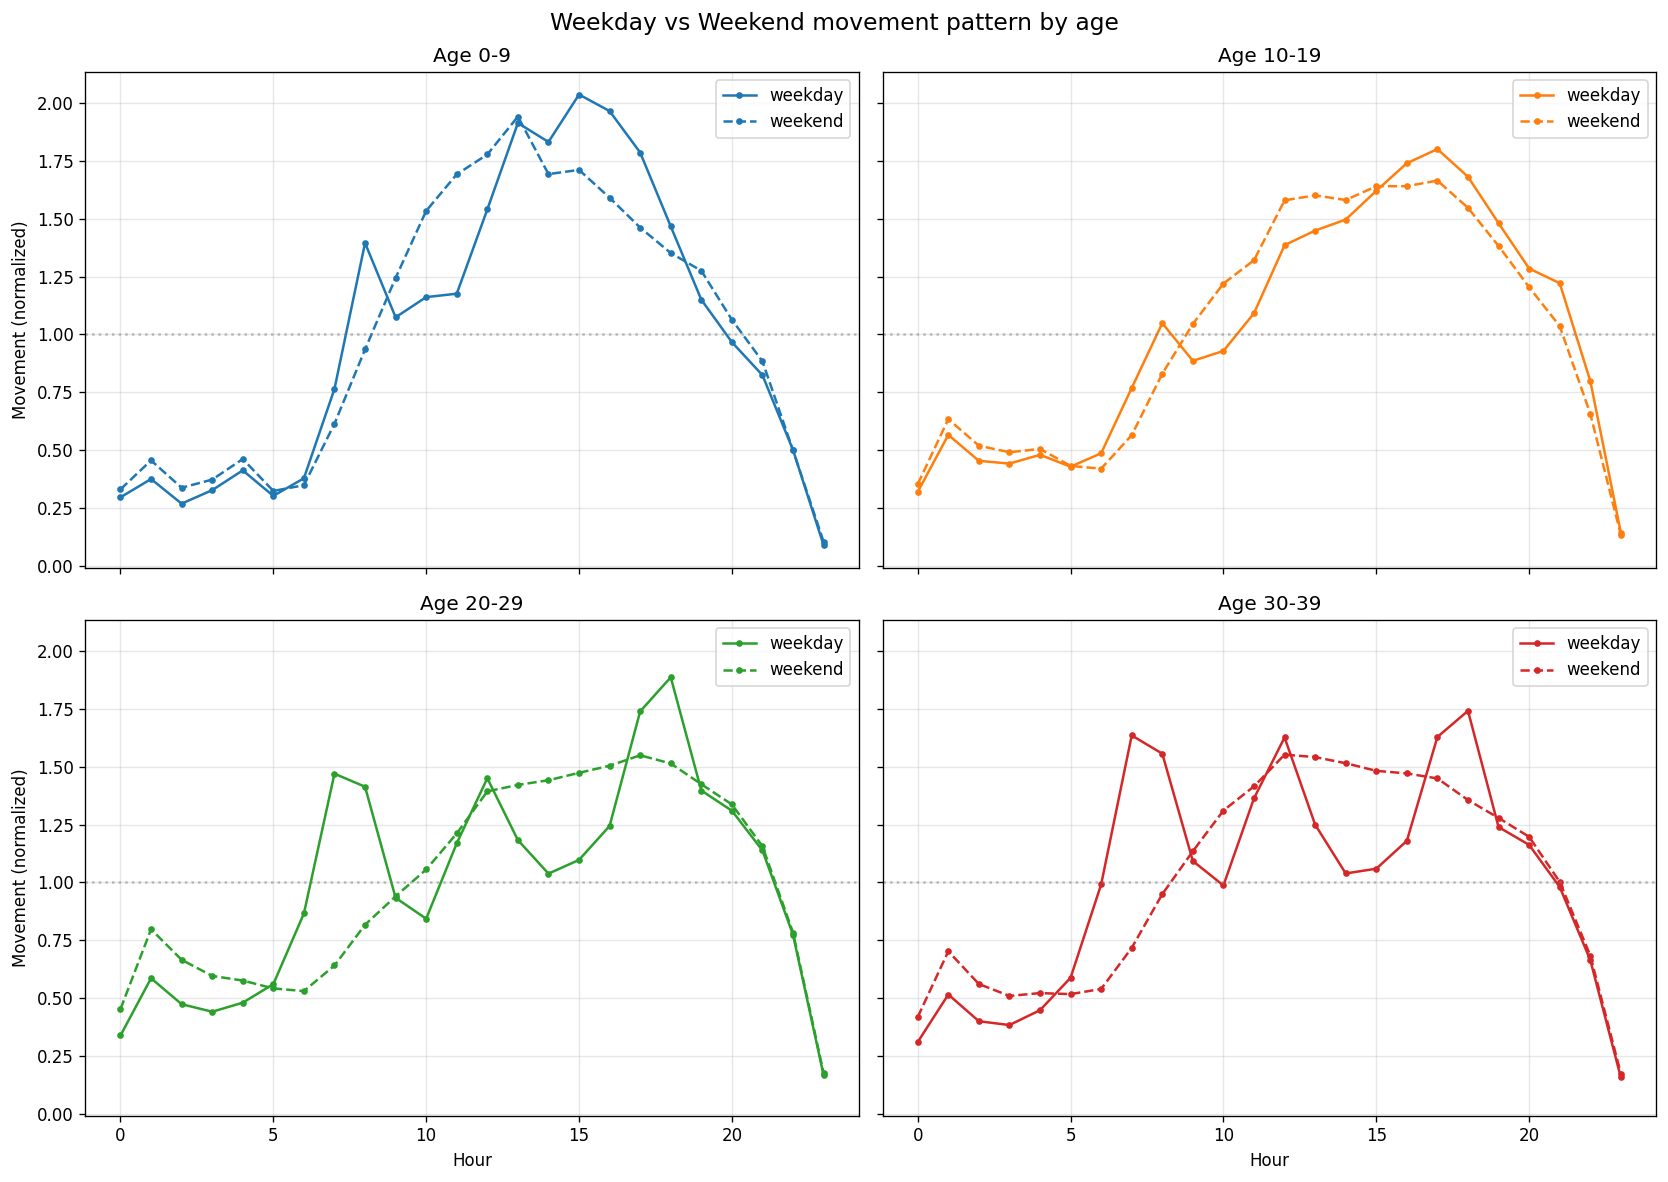

In [7]:
movement_dt = movement.with_columns(
    pl.col('date').map_elements(classify_day, return_dtype=pl.Utf8).alias('day_type')
)

day_type_pattern = (
    movement_dt.group_by(['day_type', 'hour', 'age_10'])
               .agg(pl.col('total').sum().alias('moves'))
)
day_type_pattern = day_type_pattern.with_columns(
    (pl.col('moves') / pl.col('moves').mean().over(['age_10', 'day_type']))
    .alias('moves_norm')
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
for idx, age in enumerate(ALL_AGES):
    ax = axes[idx // 2, idx % 2]
    for day_type, ls in [('weekday', '-'), ('weekend', '--')]:
        sub = (day_type_pattern
               .filter((pl.col('age_10') == age) &
                       (pl.col('day_type') == day_type))
               .sort('hour'))
        ax.plot(sub['hour'].to_numpy(), sub['moves_norm'].to_numpy(),
                label=day_type, linestyle=ls, color=AGE_COLORS[age],
                marker='o', markersize=3)
    ax.set_title(f'Age {AGE_LABELS[age]}')
    ax.axhline(1.0, color='gray', linestyle=':', alpha=0.5)
    ax.legend()
    ax.grid(True, alpha=0.3)
    if idx // 2 == 1:
        ax.set_xlabel('Hour')
    if idx % 2 == 0:
        ax.set_ylabel('Movement (normalized)')
plt.suptitle('Weekday vs Weekend movement pattern by age', fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / '06_weekday_vs_weekend.png', dpi=120)
plt.show()

## 7. 평일 9시 — 0–9 / 10–19세는 어디에 있나?

> **결정적 검증 단계**.
> 
> 평일 9시 (어린이집·초등 등교 시작) 인구 분포가, 같은 시각의 주말 분포와 다르면
> → 어린이가 학교/어린이집 위치로 이동하고 KT가 그 이동을 잡고 있다는 증거.
> 
> 거의 같다면 → KT가 어린이의 통학 이동을 잡지 못하거나, 1월(방학)이어서 통학이 실제로 없거나.
> 1월 방학 한계 때문에 본 셀의 결과는 "학기 중 데이터(2023-05/10)"로 다시 봐야 결정적임. 1월에서도 강한 신호가 보이면 학원/돌봄 이동의 증거.

9시 평일-주말 인구 차이 (행정동, 상대 변화):
shape: (4, 5)
┌────────┬─────────────────┬───────────┬──────────┬───────────────┐
│ age_10 ┆ median_rel_diff ┆ q10       ┆ q90      ┆ sum_diff      │
│ ---    ┆ ---             ┆ ---       ┆ ---      ┆ ---           │
│ i8     ┆ f64             ┆ f64       ┆ f64      ┆ f64           │
╞════════╪═════════════════╪═══════════╪══════════╪═══════════════╡
│ 0      ┆ 0.037174        ┆ -0.278137 ┆ 0.204382 ┆ 12827.302088  │
│ 10     ┆ 0.020574        ┆ -0.153765 ┆ 0.140064 ┆ 89997.4515    │
│ 20     ┆ -0.108513       ┆ -0.238087 ┆ 0.377813 ┆ 133191.306    │
│ 30     ┆ -0.141349       ┆ -0.308198 ┆ 0.465791 ┆ 141777.410364 │
└────────┴─────────────────┴───────────┴──────────┴───────────────┘

0-9세 9시 평일이 주말보다 가장 많이 증가한 행정동 top 10 (어린이집/돌봄 후보):
shape: (10, 7)
┌────────────┬────────────┬────────┬───────────┬─────────────┬────────────┬──────────┐
│ admdong_cd ┆ admdong_nm ┆ age_10 ┆ weekday   ┆ weekend     ┆ diff       ┆ rel_diff │
│ ---        ┆ ---        ┆ ---    

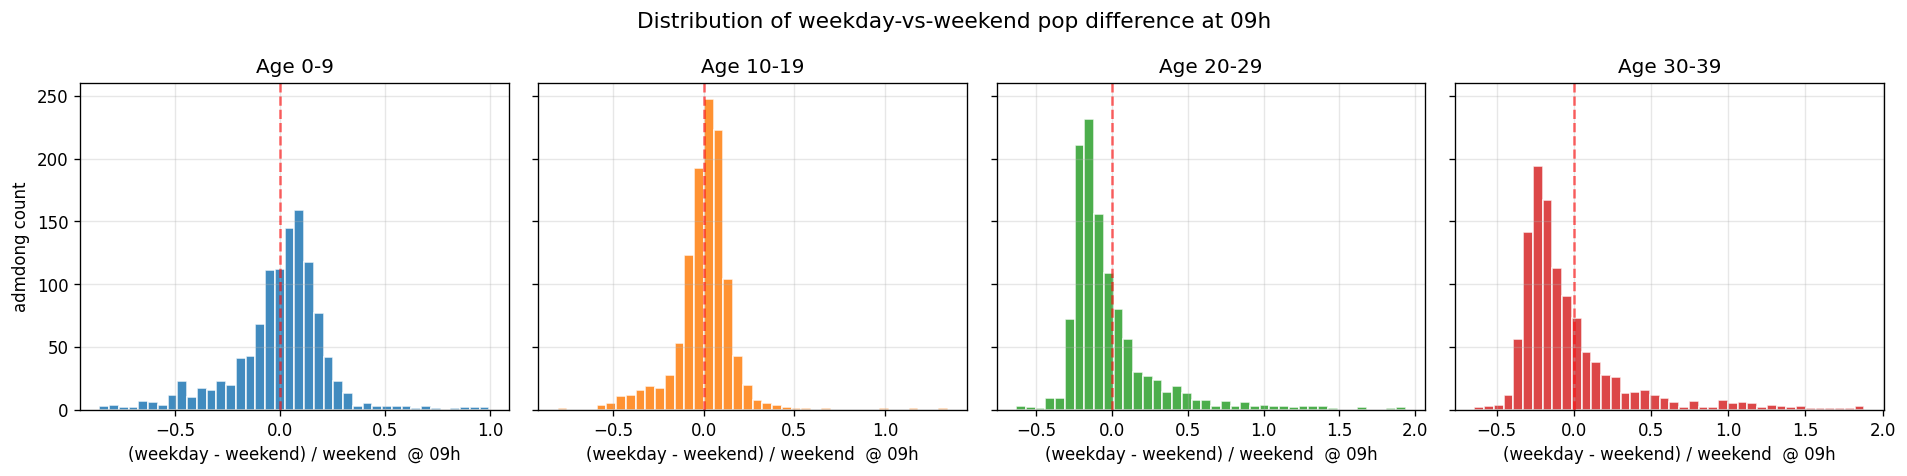

In [8]:
livepop_dt = livepop.with_columns(
    pl.col('date').map_elements(classify_day, return_dtype=pl.Utf8).alias('day_type')
)

hour9 = (
    livepop_dt.filter(pl.col('hour') == 9)
              .group_by(['admdong_cd', 'admdong_nm', 'age_10', 'day_type'])
              .agg(pl.col('pop').mean().alias('pop_avg'))
)
hour9_pivot = (
    hour9.pivot(on='day_type',
                index=['admdong_cd', 'admdong_nm', 'age_10'],
                values='pop_avg')
         .with_columns([
             (pl.col('weekday') - pl.col('weekend')).alias('diff'),
             ((pl.col('weekday') - pl.col('weekend')) / pl.col('weekend'))
             .alias('rel_diff'),
         ])
         .filter(pl.col('weekend') > 10)
)

print('9시 평일-주말 인구 차이 (행정동, 상대 변화):')
summary9 = (
    hour9_pivot.group_by('age_10')
               .agg([
                   pl.col('rel_diff').median().alias('median_rel_diff'),
                   pl.col('rel_diff').quantile(0.10).alias('q10'),
                   pl.col('rel_diff').quantile(0.90).alias('q90'),
                   pl.col('diff').sum().alias('sum_diff'),
               ])
               .sort('age_10')
)
print(summary9)

print('\n0-9세 9시 평일이 주말보다 가장 많이 증가한 행정동 top 10 (어린이집/돌봄 후보):')
print(hour9_pivot.filter(pl.col('age_10') == 0)
                 .sort('diff', descending=True)
                 .head(10))

print('\n10-19세 9시 평일이 주말보다 가장 많이 증가한 행정동 top 10:')
print(hour9_pivot.filter(pl.col('age_10') == 10)
                 .sort('diff', descending=True)
                 .head(10))

# 분포 시각화: rel_diff 히스토그램 (연령별)
fig, axes = plt.subplots(1, len(ALL_AGES), figsize=(16, 4), sharey=True)
for ax, age in zip(axes, ALL_AGES):
    vals = (hour9_pivot.filter(pl.col('age_10') == age)['rel_diff']
                       .drop_nulls().to_numpy())
    vals = vals[(vals > -2) & (vals < 2)]   # 극단치 컷
    ax.hist(vals, bins=40, color=AGE_COLORS[age], alpha=0.85,
            edgecolor='white')
    ax.axvline(0, color='r', linestyle='--', alpha=0.6)
    ax.set_title(f'Age {AGE_LABELS[age]}')
    ax.set_xlabel('(weekday - weekend) / weekend  @ 09h')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('admdong count')
plt.suptitle('Distribution of weekday-vs-weekend pop difference at 09h', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR / '07_hour9_weekday_vs_weekend.png', dpi=120)
plt.show()

## 8. 종합 — Mobility 신뢰성 자체 평가

> 위 섹션 지표를 한 표로 모음.
> 
> - `pop_hourly_CV`: 시간대 변동 계수 (정규화 인구의 std/mean) — 클수록 "낮밤 차"가 큼
> - `move_hourly_CV`: 동일하지만 이동량 기준
> - `day_night_ratio_median`: 행정동 중앙값
> - `moves_per_capita_month`: 인당 월 이동 횟수
> 
> 마지막에 **20–29세를 1.0으로 놓고 다른 연령의 비율**을 출력. 0–9세 비율이 0.1 이하 등 매우 작으면 → 분석에 쓸 때 큰 보정/주의가 필요.

In [9]:
indicators = []
for age in ALL_AGES:
    sub_pop = age_avg_pop.filter(pl.col('age_10') == age)['avg_pop_total'][0]
    sub_move = merged.filter(pl.col('age_10') == age)['moves_per_person_month'][0]
    sub_dn = day_night.filter(pl.col('age_10') == age)['day_night_ratio'].median()

    hp = hourly_norm.filter(pl.col('age_10') == age).sort('hour')
    pop_cv = float(hp['pop_normalized'].std() / hp['pop_normalized'].mean())

    hm = hourly_move_norm.filter(pl.col('age_10') == age).sort('hour')
    move_cv = float(hm['moves_normalized'].std() / hm['moves_normalized'].mean())

    indicators.append({
        'age': AGE_LABELS[age],
        'avg_pop': round(sub_pop),
        'moves_per_capita_month': round(sub_move, 2),
        'pop_hourly_CV': round(pop_cv, 3),
        'move_hourly_CV': round(move_cv, 3),
        'day_night_ratio_median': round(sub_dn, 3),
    })

indicator_df = pd.DataFrame(indicators)
print(indicator_df.to_string(index=False))

ref_pop = indicator_df.loc[indicator_df['age'] == '20-29', 'avg_pop'].iloc[0]
ref_moves = indicator_df.loc[indicator_df['age'] == '20-29',
                             'moves_per_capita_month'].iloc[0]
print('\n20-29 대비 비율:')
for _, row in indicator_df.iterrows():
    print(f"  {row['age']:>5}: pop_ratio={row['avg_pop']/ref_pop:.2f}  "
          f"moves_per_cap_ratio={row['moves_per_capita_month']/ref_moves:.2f}")

indicator_df.to_csv(OUT_DIR / '08_summary_indicators.csv', index=False)
print(f"\nsaved: {OUT_DIR / '08_summary_indicators.csv'}")

  age  avg_pop  moves_per_capita_month  pop_hourly_CV  move_hourly_CV  day_night_ratio_median
  0-9   282791                   26.67          0.002           0.610                   0.998
10-19  2201864                   30.78          0.001           0.505                   0.960
20-29  3271743                   42.75          0.001           0.424                   0.877
30-39  3486964                   45.21          0.001           0.438                   0.870

20-29 대비 비율:
    0-9: pop_ratio=0.09  moves_per_cap_ratio=0.62
  10-19: pop_ratio=0.67  moves_per_cap_ratio=0.72
  20-29: pop_ratio=1.00  moves_per_cap_ratio=1.00
  30-39: pop_ratio=1.07  moves_per_cap_ratio=1.06

saved: ../outputs/age_validation_2023_01/08_summary_indicators.csv


## 9. 결론 및 다음 단계

**1월 데이터 한정 결론 — 셀 실행 후 채울 것**

- [ ] 0–9세의 LivePOP 시간 변동(CV), day-night ratio가 성인 대비 얼마나 작은지?
- [ ] 0–9세의 인당 월 이동 횟수가 20–29 대비 몇 % 수준인지?
- [ ] 평일 9시 어린이 인구 증가 행정동 top10이 "실제 어린이집/초등학교 밀집지"와 일치하는가?
- [ ] 10–19세 평일 17–22시 학원 시간대 mobility 봉오리가 관측되는가?

**1월로는 결론 못 내는 부분 (학기 중 데이터로 보강 필요)**

- 통학 이동량 자체 — 1월은 방학.
- 평일 등하교(8시·15시·17시) 피크 유무.
- 학교 위치 행정동의 평일 주간 인구 증가폭.

**Phase 3 (Movement 72개월 정제) 이후 반복할 것**

- 같은 분석을 2023-05 (1학기 중반) 또는 2023-10 (2학기 중반)에 적용.
- 1월 결과와 비교 → "방학/학기 차이"가 KT 데이터에 잡히는 정도가 어린이 데이터 신뢰도의 직접 증거.
- 결론은 학기 중 결과까지 본 후 보고서/논문에 들어가야 함.

## 10. 주민등록 비교 (KT 검출률 정량화)

> **여기서부터는 외부 데이터(행안부 주민등록) 비교 셀이다.**
> 
> 가정:
> 
> - LivePOP 03–05시 평균 ≒ "거주 인구 추정값" (이 시간엔 대부분 집에 있음)
> - MOIS 주민등록 인구 = 공식 거주 인구
> - **KT 검출률 := KT 야간 평균 / MOIS 주민등록**
> 
> 연령별·행정동별 검출률 분포를 본다.
> 
> - 검출률 < 1: KT가 그 연령을 못 잡음
> - 0–9세 검출률이 매우 낮으면 → 휴대폰 미보유 + KT 보정 한계
> - 10–19세도 낮으면 → 학교/학원 보정 안 됨 (1월은 학교 안 가지만 어린이집·학원 미반영)
> - 20–30대 검출률이 ~1에 가까우면 → 그 연령은 KT 신뢰 가능
> 
> 데이터 한계:
> 
> - MOIS = 2023-01 월말 기준. LivePOP = 1월 24×31시간 평균. 시점이 정확히 같지는 않음.
> - MOIS 1,154개 행정동 중 1,148개가 KT 매핑과 매칭 (99.5%). 6개 결측은 옹진군 출장소 등.
> - KT 매핑 1,314개 중 166개는 MOIS에 없음 (변경된 행정동 코드 등) — 비교 대상에서 자동 제외됨.

In [10]:
mois = pl.read_parquet(MAPPING_DIR / 'mois_population_202301_age10.parquet')
print(f'MOIS rows: {mois.height:,}  | admdongs: {mois["admdong_cd"].n_unique():,}')

# 야간 평균 (03-05시): 일별 합 → 시간/일 평균
night_livepop = (
    livepop.filter(pl.col('hour').is_in([3, 4, 5]))
           .group_by(['admdong_cd', 'admdong_nm', 'age_10'])
           .agg(pl.col('pop').mean().alias('kt_night_avg'))
)

comparison = (
    night_livepop.join(
        mois.select(['admdong_cd', 'age_10', 'pop'])
            .rename({'pop': 'mois_pop'}),
        on=['admdong_cd', 'age_10'],
        how='inner',
    )
    .filter(pl.col('mois_pop') > 0)
    .with_columns(
        (pl.col('kt_night_avg') / pl.col('mois_pop')).alias('detection_rate')
    )
)

print(f'\nJoined rows: {comparison.height:,}  '
      f'(across {comparison["admdong_cd"].n_unique():,} admdongs × {len(ALL_AGES)} ages)')

print('\n연령대별 검출률 (KT 야간 / MOIS):')
summary_det = (
    comparison.group_by('age_10')
              .agg([
                  pl.col('detection_rate').median().alias('median'),
                  pl.col('detection_rate').mean().alias('mean'),
                  pl.col('detection_rate').quantile(0.25).alias('q25'),
                  pl.col('detection_rate').quantile(0.75).alias('q75'),
                  pl.col('detection_rate').std().alias('std'),
                  pl.len().alias('n_admdongs'),
              ])
              .sort('age_10')
)
print(summary_det)

# 20-29 대비 비율
ref_median = summary_det.filter(pl.col('age_10') == 20)['median'][0]
print('\n20-29세 검출률 중앙값을 1.0으로 놓았을 때 다른 연령의 상대 비율:')
for row in summary_det.iter_rows(named=True):
    age_lbl = AGE_LABELS.get(row['age_10'], str(row['age_10']))
    print(f'  {age_lbl:>5}: median={row["median"]:.3f}  '
          f'rel_to_2029={row["median"]/ref_median:.2f}')

summary_det.write_csv(OUT_DIR / '09_detection_rate_summary.csv')

MOIS rows: 10,386  | admdongs: 1,154

Joined rows: 4,590  (across 1,148 admdongs × 4 ages)

연령대별 검출률 (KT 야간 / MOIS):
shape: (4, 7)
┌────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────────┐
│ age_10 ┆ median   ┆ mean     ┆ q25      ┆ q75      ┆ std      ┆ n_admdongs │
│ ---    ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---      ┆ ---        │
│ i8     ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ f64      ┆ u32        │
╞════════╪══════════╪══════════╪══════════╪══════════╪══════════╪════════════╡
│ 0      ┆ 0.148337 ┆ 0.179118 ┆ 0.114965 ┆ 0.192801 ┆ 0.169209 ┆ 1146       │
│ 10     ┆ 0.945987 ┆ 1.113938 ┆ 0.892853 ┆ 1.047455 ┆ 2.258536 ┆ 1148       │
│ 20     ┆ 0.91977  ┆ 1.252763 ┆ 0.861527 ┆ 1.024993 ┆ 6.310487 ┆ 1148       │
│ 30     ┆ 0.939013 ┆ 1.043569 ┆ 0.884332 ┆ 1.022656 ┆ 1.04928  ┆ 1148       │
└────────┴──────────┴──────────┴──────────┴──────────┴──────────┴────────────┘

20-29세 검출률 중앙값을 1.0으로 놓았을 때 다른 연령의 상대 비율:
    0-9: median=0.148  rel_to_2029=0

/var/folders/p6/bh0h2f651z556fbmr892wdl80000gn/T/ipykernel_2453/290664745.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[AGE_LABELS[a] for a in ALL_AGES], showfliers=False)


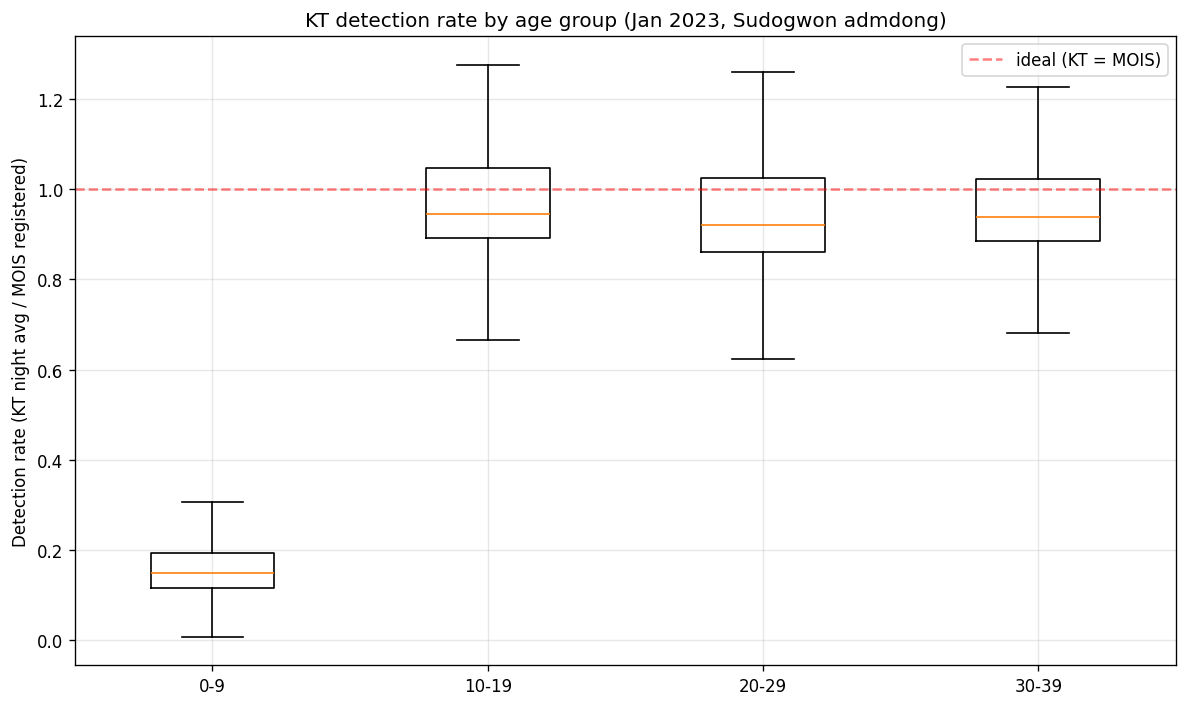

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
data = [comparison.filter(pl.col('age_10') == age)['detection_rate'].to_numpy()
        for age in ALL_AGES]
ax.boxplot(data, labels=[AGE_LABELS[a] for a in ALL_AGES], showfliers=False)
ax.set_ylabel('Detection rate (KT night avg / MOIS registered)')
ax.set_title('KT detection rate by age group (Jan 2023, Sudogwon admdong)')
ax.axhline(1.0, color='r', linestyle='--', alpha=0.5, label='ideal (KT = MOIS)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / '09_detection_rate_boxplot.png', dpi=120)
plt.show()

### 해석 가이드 (셀 실행 후 채워 넣기)

- 각 연령의 검출률 중앙값 (`median`):
  - 1.0에 가까우면 KT가 야간 거주 인구를 잘 포착
  - 1.0 미만이면 미검출 → 분석 시 보정 필요
  - 1.0 초과면 KT가 과대 추정 (관광객·유동인구 보정 효과 가능)
- **연령별 보정 가능성**: 행정동 검출률 분포의 폭(IQR, std)이 좁고 한 곳에 몰리면
  → 단순 곱셈 보정으로 충분. 분산이 크면 동별 개별 보정 필요.
- **0–9세 결과 해석 분기**:
  - 0.1 이하: KT 데이터에서 어린이는 실질적으로 사라진 수준 → mobility 분석 부적합.
  - 0.1–0.5: 보정해서 "상대 패턴"만 다룰 수 있음 (절대값 X).
  - 0.5 이상: 보정 후 분석 가능.
- 1월 결과는 baseline. 2023-05/10 데이터로 같은 분석 반복해서 "학기 효과"까지 확인 필요.

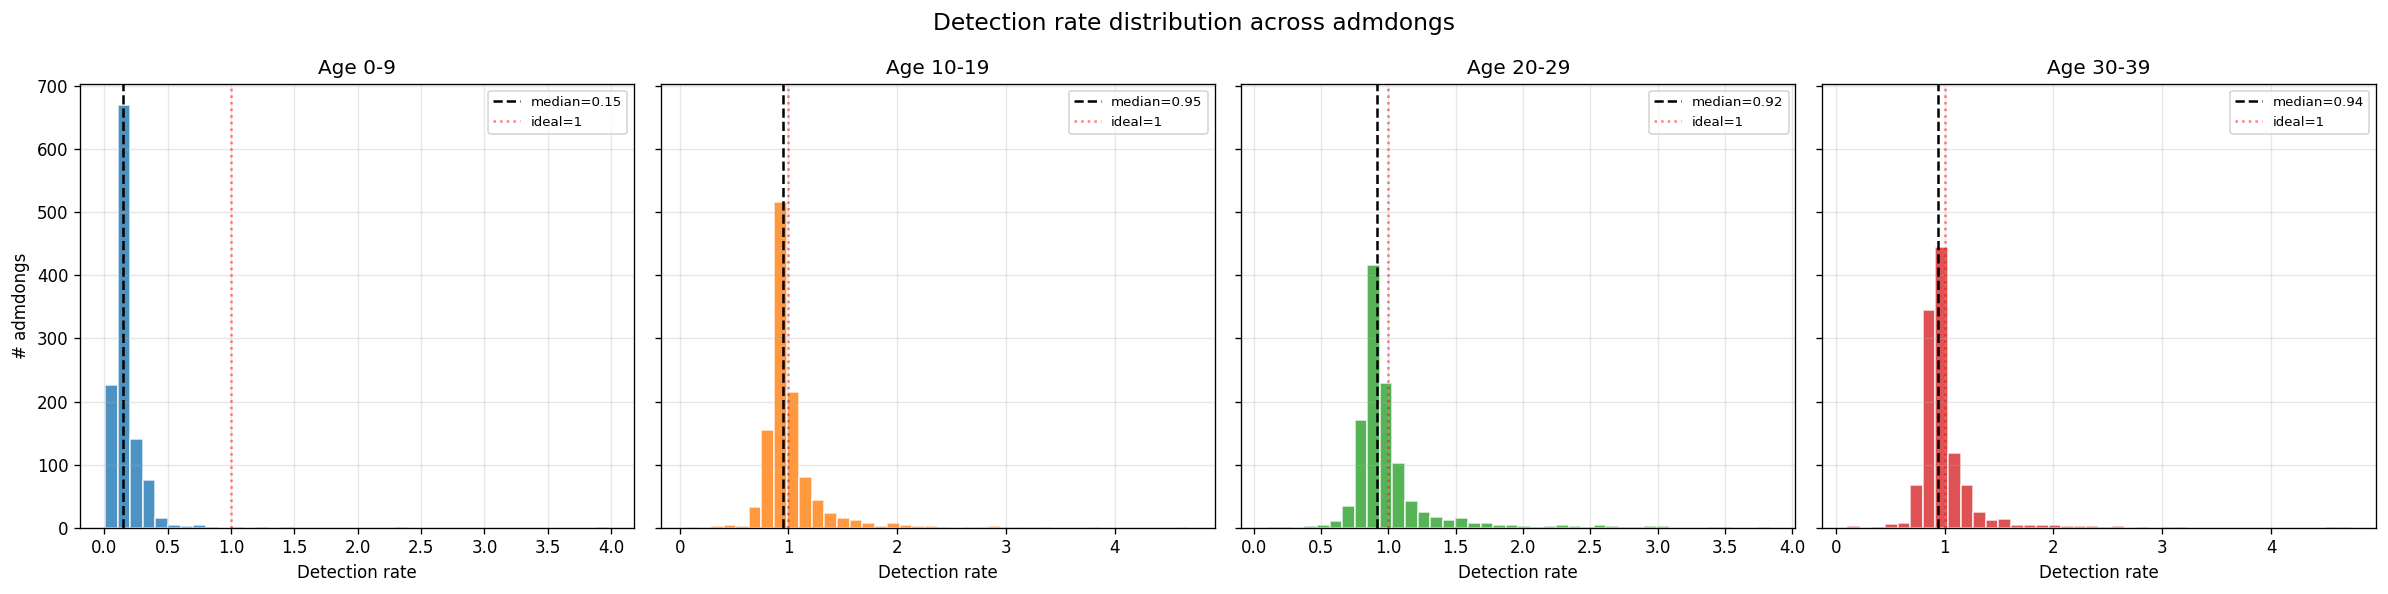

In [12]:
# 행정동별 검출률 분포 — 각 연령의 보정 가능성 평가
# 분포가 좁고 모드가 한 곳에 모이면 단순 계수 보정 가능, 넓으면 어려움.
fig, axes = plt.subplots(1, len(ALL_AGES), figsize=(20, 5), sharey=True)
for idx, age in enumerate(ALL_AGES):
    ax = axes[idx]
    rates = comparison.filter(pl.col('age_10') == age)['detection_rate'].to_numpy()
    rates_clipped = rates[(rates > 0) & (rates < 5)]   # 극단치 컷
    ax.hist(rates_clipped, bins=40, color=AGE_COLORS[age], alpha=0.8,
            edgecolor='white')
    med = float(np.median(rates))
    ax.axvline(med, color='k', linestyle='--',
               label=f'median={med:.2f}')
    ax.axvline(1.0, color='r', linestyle=':', alpha=0.5, label='ideal=1')
    ax.set_title(f'Age {AGE_LABELS[age]}')
    ax.set_xlabel('Detection rate')
    if idx == 0:
        ax.set_ylabel('# admdongs')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
plt.suptitle('Detection rate distribution across admdongs', fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / '10_detection_rate_distribution.png', dpi=120)
plt.show()

## 10. 전 연령대 검출률 분석

발표 피드백 반영:
1. 기존 분석은 0-9, 10-19, 20-29, 30-39만 다룸 → **전 연령 (0-9 ~ 70+) 확장**
2. IQR이 넓은 이유 정량 분석:
   - 야간에도 거주지에 없는 인구 (호텔/병원/24시간 사업장)
   - 외국인 거주 비율
   - 주민등록 vs 실거주 mismatch
   - 행정동 인구 규모 효과
3. 70+ 그룹은 휴대폰 보급률 낮을 가능성 확인

In [ ]:
ALL_AGES_FULL = [0, 10, 20, 30, 40, 50, 60, 70]
AGE_LABELS_FULL = {0: '0-9', 10: '10-19', 20: '20-29', 30: '30-39',
                   40: '40-49', 50: '50-59', 60: '60-69', 70: '70+'}
AGE_COLORS_FULL = {0: 'C0', 10: 'C1', 20: 'C2', 30: 'C3',
                   40: 'C4', 50: 'C5', 60: 'C6', 70: 'C7'}

livepop = pl.read_parquet(DATA_DIR / 'livepop_sudogwon_202301.parquet')
mois = pl.read_parquet(MAPPING_DIR / 'mois_population_202301_age10.parquet')

night_livepop = (
    livepop.filter(pl.col('hour').is_in([3, 4, 5]))
    .group_by(['admdong_cd', 'admdong_nm', 'age_10'])
    .agg(pl.col('pop').mean().alias('kt_night_avg'))
)

comparison_full = (
    night_livepop.join(
        mois.select(['admdong_cd', 'age_10', 'pop']).rename({'pop': 'mois_pop'}),
        on=['admdong_cd', 'age_10'], how='inner',
    )
    .with_columns((pl.col('kt_night_avg') / pl.col('mois_pop')).alias('detection_rate'))
    .filter(pl.col('mois_pop') > 50)  # 인구 너무 적은 행정동 제외
)

summary_full = (
    comparison_full.group_by('age_10').agg([
        pl.col('detection_rate').median().alias('median'),
        pl.col('detection_rate').mean().alias('mean'),
        pl.col('detection_rate').quantile(0.10).alias('q10'),
        pl.col('detection_rate').quantile(0.25).alias('q25'),
        pl.col('detection_rate').quantile(0.75).alias('q75'),
        pl.col('detection_rate').quantile(0.90).alias('q90'),
        pl.col('detection_rate').std().alias('std'),
        pl.len().alias('n_admdongs'),
    ]).sort('age_10')
)
print("연령대별 검출률 통계 (전 연령):")
print(summary_full)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
data = [
    comparison_full.filter(pl.col('age_10') == age)['detection_rate'].to_numpy()
    for age in ALL_AGES_FULL
]
bp = ax.boxplot(
    data,
    labels=[AGE_LABELS_FULL[a] for a in ALL_AGES_FULL],
    showfliers=False,
    patch_artist=True,
)
for patch, age in zip(bp['boxes'], ALL_AGES_FULL):
    patch.set_facecolor(AGE_COLORS_FULL[age])
    patch.set_alpha(0.6)

ax.set_ylabel('Detection rate (KT night avg / MOIS registered)')
ax.set_title('KT detection rate across all age groups (Jan 2023, Sudogwon admdong)')
ax.axhline(1.0, color='r', linestyle='--', alpha=0.5, label='ideal (KT = MOIS)')
ax.set_ylim(0, 2.0)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / '10_detection_rate_all_ages.png', dpi=120)
plt.show()

## 11. IQR이 넓은 원인 분석

박스플롯의 IQR이 약 ±0.10~0.20 — 행정동 간 검출률 편차가 큼.
30% 넘게 차이나는 행정동도 다수 존재.

원인 가설을 정량적으로 확인:
1. **행정동 인구 규모** — 작은 동은 통계 noise가 큼
2. **도심 vs 외곽** — 호텔/오피스는 야간 비거주 인구 잡음
3. **시도별 차이** — 서울 / 경기 / 인천

In [ ]:
# 검출률 vs 행정동 인구 (작은 동은 분산 큰지?)
fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)

for idx, age in enumerate(ALL_AGES_FULL):
    ax = axes[idx // 4, idx % 4]
    sub = comparison_full.filter(pl.col('age_10') == age)
    ax.scatter(
        sub['mois_pop'], sub['detection_rate'],
        alpha=0.3, s=10, color=AGE_COLORS_FULL[age],
    )
    ax.axhline(1.0, color='r', linestyle='--', alpha=0.5)
    ax.set_title(f'Age {AGE_LABELS_FULL[age]}')
    ax.set_xscale('log')
    ax.set_ylim(0, 2.5)
    if idx // 4 == 1:
        ax.set_xlabel('MOIS population (log scale)')
    if idx % 4 == 0:
        ax.set_ylabel('Detection rate')
    ax.grid(True, alpha=0.3)

plt.suptitle('Detection rate vs admdong population (per age group)', fontsize=14)
plt.tight_layout()
plt.savefig(OUT_DIR / '11_detection_rate_vs_pop.png', dpi=120)
plt.show()

In [ ]:
# 시도별 검출률 — 서울 도심 (호텔/오피스) vs 경기 외곽 (주거)
def get_sido(code):
    return {'11': '서울', '28': '인천', '41': '경기'}.get(code[:2], '기타')

comparison_sido = comparison_full.with_columns(
    pl.col('admdong_cd').map_elements(get_sido, return_dtype=pl.Utf8).alias('sido')
)

sido_age = (
    comparison_sido.group_by(['sido', 'age_10']).agg([
        pl.col('detection_rate').median().alias('median'),
        pl.len().alias('n_admdongs'),
    ]).sort(['sido', 'age_10'])
)
print("시도 × 연령 검출률 중앙값:")
print(sido_age)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(ALL_AGES_FULL))
width = 0.25
sidos = ['서울', '경기', '인천']
sido_colors = {'서울': 'C0', '경기': 'C1', '인천': 'C2'}

for i, sido in enumerate(sidos):
    medians = []
    for age in ALL_AGES_FULL:
        sub = sido_age.filter((pl.col('sido') == sido) & (pl.col('age_10') == age))
        medians.append(sub['median'][0] if len(sub) > 0 else 0)
    ax.bar(x + i * width, medians, width, label=sido, color=sido_colors[sido])

ax.set_xticks(x + width)
ax.set_xticklabels([AGE_LABELS_FULL[a] for a in ALL_AGES_FULL])
ax.set_xlabel('Age group')
ax.set_ylabel('Median detection rate')
ax.set_title('Detection rate by sido and age')
ax.axhline(1.0, color='r', linestyle='--', alpha=0.5)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / '12_detection_rate_by_sido.png', dpi=120)
plt.show()

In [ ]:
# Outlier 행정동 — 20-30대 (성인 baseline)에서 검출률 > 1.3 또는 < 0.5
adults = comparison_full.filter(pl.col('age_10').is_in([20, 30]))

print("20-30대 검출률 > 1.3 행정동 (도심 호텔/오피스 추정):")
high = adults.filter(pl.col('detection_rate') > 1.3).sort('detection_rate', descending=True)
print(high.head(20).select(
    ['admdong_cd', 'admdong_nm', 'age_10', 'mois_pop', 'kt_night_avg', 'detection_rate']
))

print("\n20-30대 검출률 < 0.5 행정동 (KT 매우 누락):")
low = adults.filter(pl.col('detection_rate') < 0.5).sort('detection_rate')
print(low.head(20).select(
    ['admdong_cd', 'admdong_nm', 'age_10', 'mois_pop', 'kt_night_avg', 'detection_rate']
))

## 12. 70+ 그룹 상세 분석

70+ 검출률 패턴이 다른 연령과 어떻게 다른지 확인.

In [ ]:
age_70 = comparison_full.filter(pl.col('age_10') == 70)
print(f"70+ 행정동 수: {len(age_70):,}")
print("\n70+ 검출률 분포:")
print(age_70.select([
    pl.col('detection_rate').quantile(0.05).alias('p5'),
    pl.col('detection_rate').quantile(0.10).alias('p10'),
    pl.col('detection_rate').quantile(0.25).alias('p25'),
    pl.col('detection_rate').median().alias('p50'),
    pl.col('detection_rate').quantile(0.75).alias('p75'),
    pl.col('detection_rate').quantile(0.90).alias('p90'),
    pl.col('detection_rate').quantile(0.95).alias('p95'),
    pl.col('detection_rate').mean().alias('mean'),
]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rates_70 = age_70['detection_rate'].to_numpy()
axes[0].hist(rates_70, bins=40, color='C7', alpha=0.7)
axes[0].axvline(np.median(rates_70), color='k', linestyle='--',
                label=f'median={np.median(rates_70):.2f}')
axes[0].axvline(1.0, color='r', linestyle='--', alpha=0.5, label='ideal (1.0)')
axes[0].set_xlabel('Detection rate')
axes[0].set_ylabel('# admdongs')
axes[0].set_title('70+ detection rate distribution')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

rates_20 = comparison_full.filter(pl.col('age_10') == 20)['detection_rate'].to_numpy()
axes[1].hist(rates_20, bins=40, color='C2', alpha=0.5, label='20-29')
axes[1].hist(rates_70, bins=40, color='C7', alpha=0.5, label='70+')
axes[1].set_xlabel('Detection rate')
axes[1].set_ylabel('# admdongs')
axes[1].set_title('20-29 vs 70+ comparison')
axes[1].axvline(1.0, color='r', linestyle='--', alpha=0.5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / '13_age_70plus_detail.png', dpi=120)
plt.show()

### 해석 가이드 — 발표 답변 정리

**IQR이 넓은 이유**
1. **야간에도 비거주 인구**: 호텔/병원/24시간 사업장 (도심 행정동에서 detection > 1)
2. **외국인**: KT 단말 보유 외국인은 잡히지만 주민등록 분모에는 빠짐 → 분자 과대
3. **거주불명 / 위장전입**: 청년 원룸 지역에서 흔함 → 분모 과대
4. **작은 행정동 noise**: 인구 1만 미만에서 단순 표본 잡음 큼

**모델에서 처리 방침**
- 행정동별 검출률은 무시, **연령별 중앙값을 보정 계수**로 사용
- **0–9 / 70+** 는 mobility 자체를 사용 안 함 (정적 모델)
- 10–69대는 평균 보정 (`× 1 / median`) 후 model input
- 시도별 보정은 도입하지 않음 (효과 작고 복잡도 증가)